# **Step 1: Data Loading and Understanding**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/wholesale+customers.zip")

In [3]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [4]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [5]:
df.dtypes

,0
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicassen,int64


In [6]:
df.shape

(440, 8)

In [7]:
df.isna().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


# **Step 2: Data Cleaning & Preparation**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dropna()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [10]:
numerical_features = df.drop(columns=["Channel", "Region"], errors='ignore')
numerical_features.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_features.columns)
scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [12]:
scaled_df.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


# **Step 3: Exploratory Data Analysis**

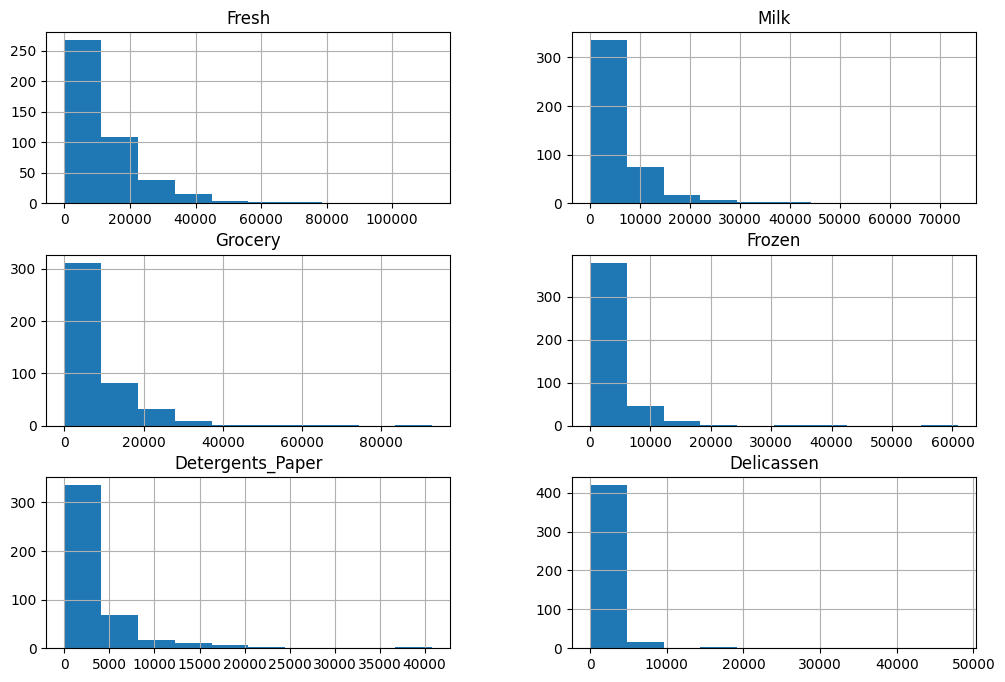

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_features.hist(figsize=(12,8))
plt.show()

In [14]:
numerical_features.skew().sort_values(ascending=False)

,0
Delicassen,11.151586
Frozen,5.907986
Milk,4.053755
Detergents_Paper,3.631851
Grocery,3.587429
Fresh,2.561323


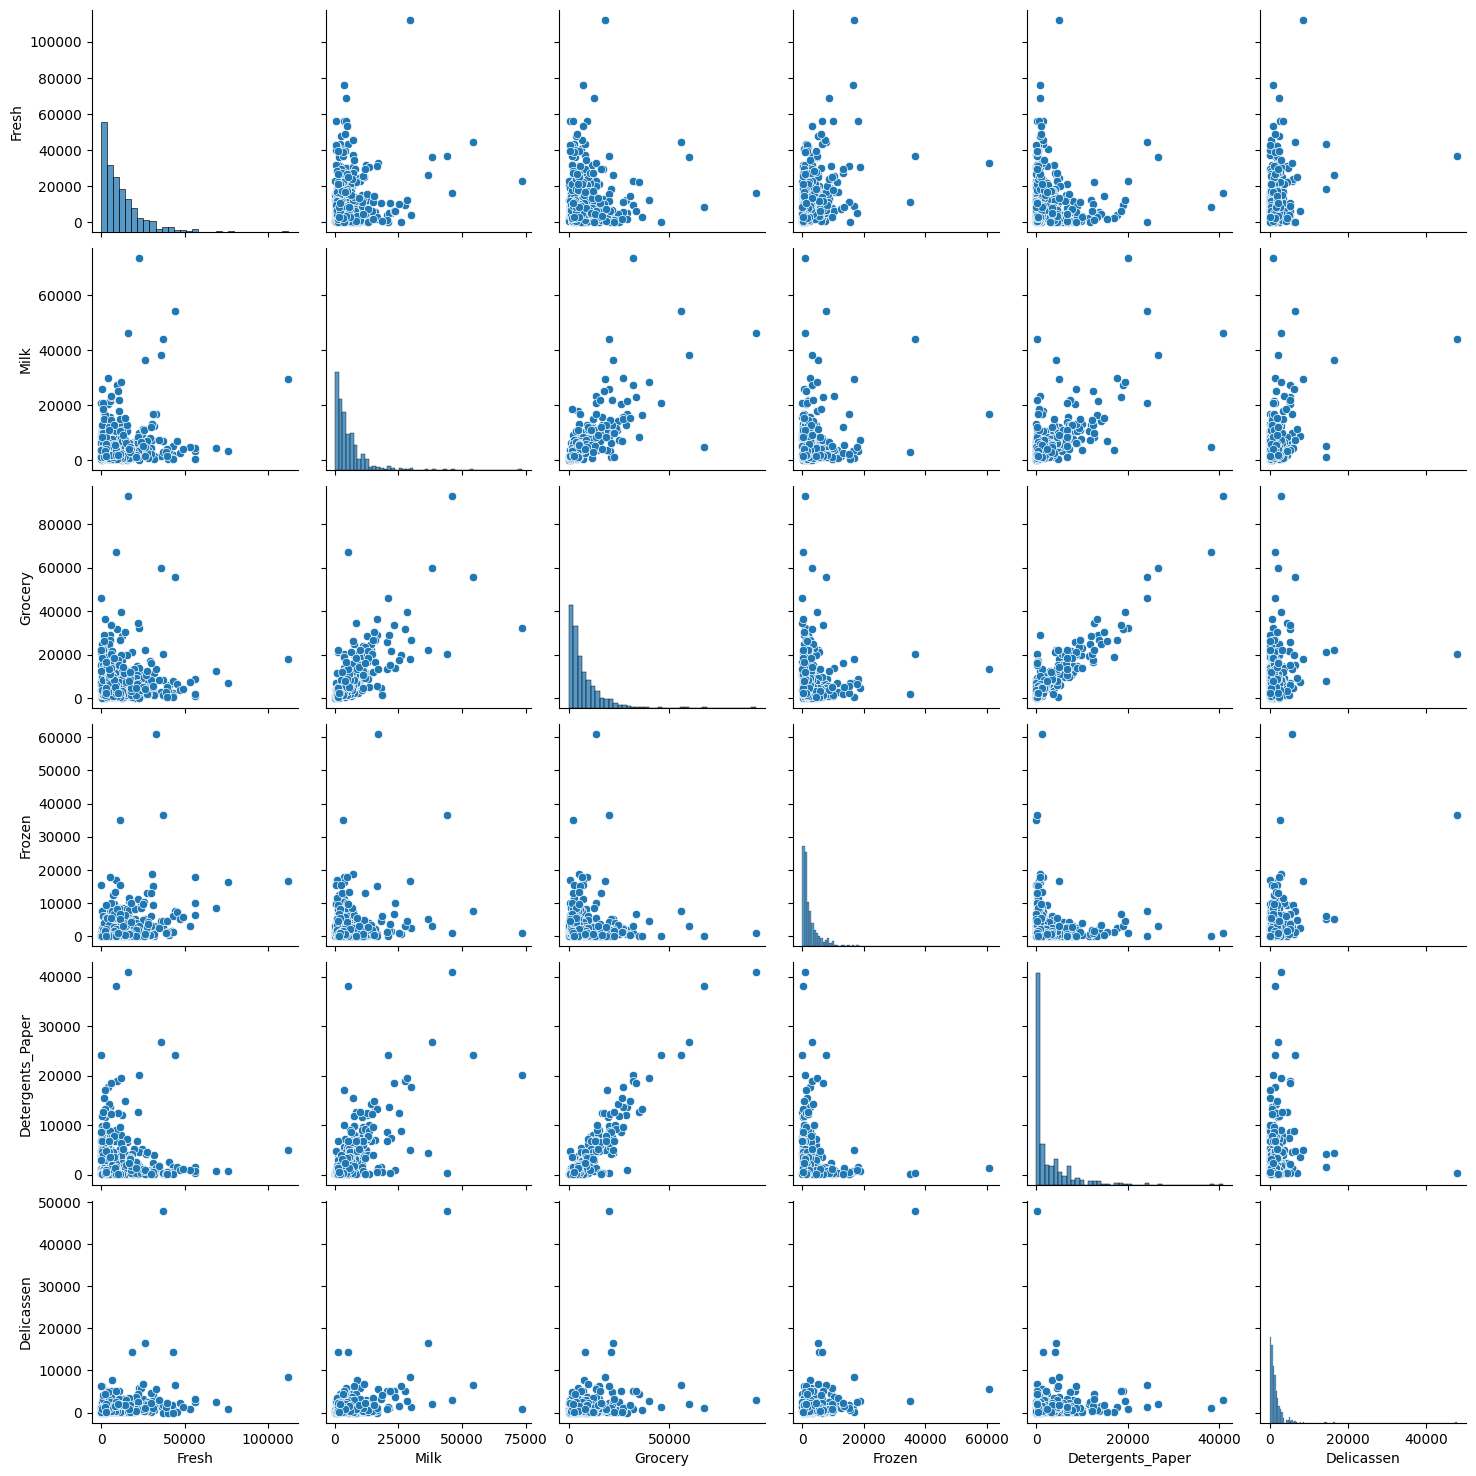

In [15]:
sns.pairplot(numerical_features)
plt.show()

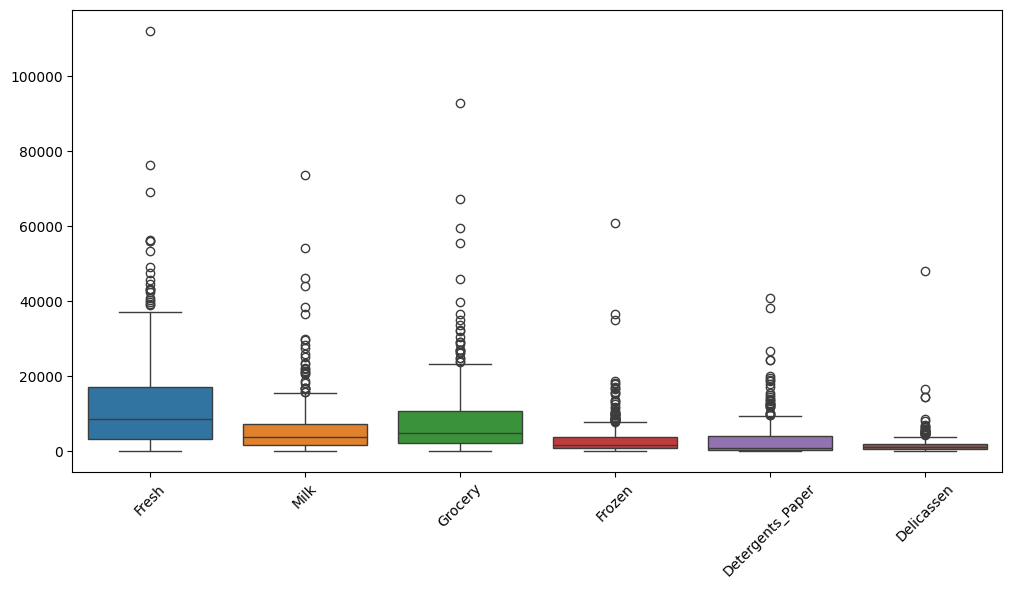

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=numerical_features)
plt.xticks(rotation=45)
plt.show()

# **Step 4: K-Means Clustering**

In [17]:
from sklearn.cluster import KMeans

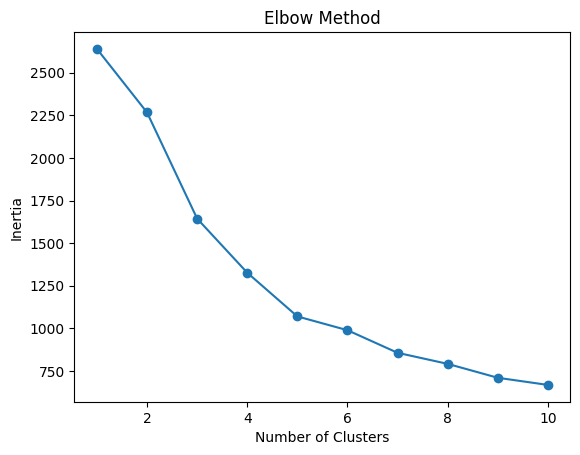

In [18]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [19]:
from sklearn.metrics import silhouette_score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.3998278091730005
K=3, Silhouette Score=0.4582633767207058
K=4, Silhouette Score=0.34939129340421093
K=5, Silhouette Score=0.36890127429678043
K=6, Silhouette Score=0.2762464573058837
K=7, Silhouette Score=0.276678268663421
K=8, Silhouette Score=0.32366546538940916
K=9, Silhouette Score=0.29453704649783113
K=10, Silhouette Score=0.22876866444760022


In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(scaled_df)
kmeans

KMeans(n_clusters=3, random_state=42)

In [22]:
df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
0,350
1,53
2,37


In [23]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=numerical_features.columns)
centroids

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000
1,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283
2,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351


# **Step 5: Hierarchical Clustering**

In [24]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=3)
df["Hierarchical_Cluster"] = agg.fit_predict(scaled_df)

In [25]:
for linkage in ["ward", "complete", "average"]:
    model = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = model.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    print(f"{linkage} linkage → Silhouette Score: {score}")

ward linkage → Silhouette Score: 0.2646091480214908
complete linkage → Silhouette Score: 0.7115312932799636
average linkage → Silhouette Score: 0.7675801420229833


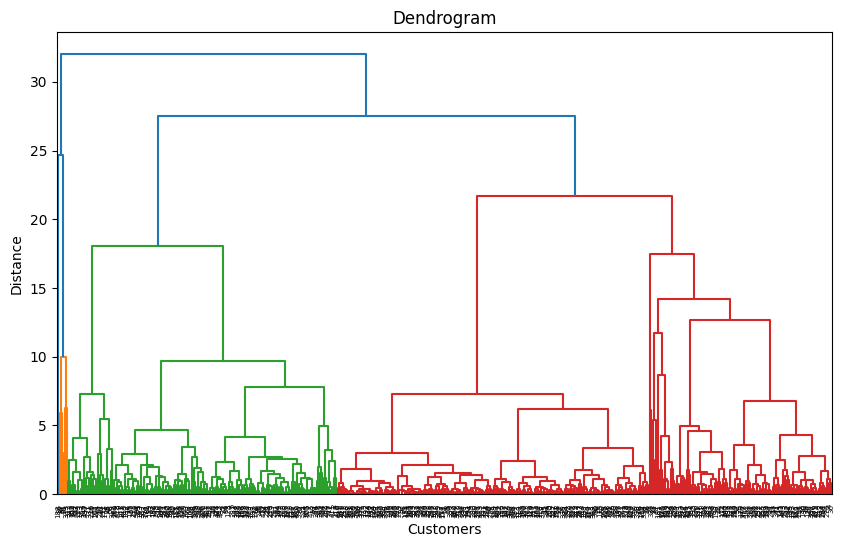

In [26]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(
    sch.linkage(scaled_df, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [27]:
silhouette_score(scaled_df, df["KMeans_Cluster"])
silhouette_score(scaled_df, df["Hierarchical_Cluster"])

np.float64(0.2646091480214908)